C:\Users\hp\AppData\Local\Temp\ipykernel_28832\3250755190.py:30: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")
C:\Users\hp\AppData\Local\Temp\ipykernel_28832\3250755190.py:64: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


Features used: ['Province', 'PostalCode', 'VehicleType', 'Model', 'CustomValueEstimate', 'Cylinders', 'VehicleAge', 'Gender']
Categorical columns: ['Province', 'VehicleType', 'Model', 'Gender']
Numerical columns: ['PostalCode', 'CustomValueEstimate', 'Cylinders', 'VehicleAge']
Regression train shape: (800078, 8)
Classification train shape: (800078, 8)
Linear Regression Results
RMSE: 2210.516613225479
R2 Score: 6.935636215343877e-07
Random Forest Regression Results
RMSE: 2220.2415161296617
R2 Score: -0.008817415161354702
XGBoost Regression Results
RMSE: 2212.1497242437235
R2 Score: -0.0014774343452157446


c:\Users\hp\insurance-risk-analytics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest Classification Results
Accuracy: 0.9970952904709529
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\hp\insurance-risk-analytics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


XGBoost Classification Results
Accuracy: 0.9970952904709529
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


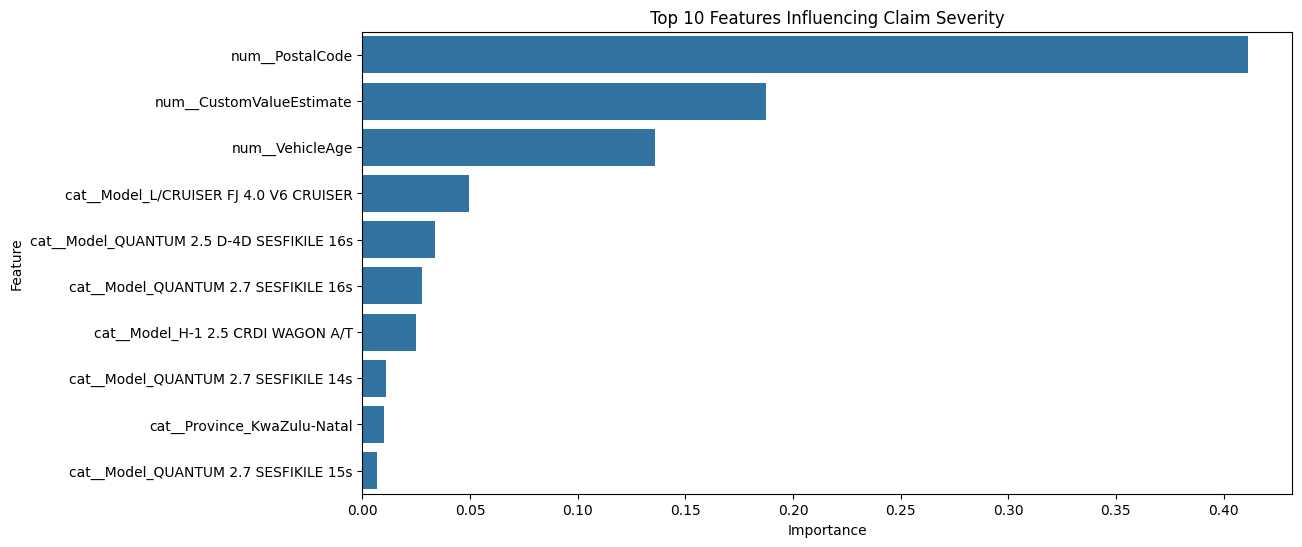

,Predicted Claim Probability,Predicted Claim Severity,Recommended Premium
0,0.000000,0.000000,0.000000
1,0.003495,105.853243,0.462460
2,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000
4,0.001701,29.913948,0.063588
5,0.006428,220.404431,1.770933
6,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000
8,0.003480,98.190740,0.427142
9,0.000000,0.000000,0.000000


In [6]:
# ==============================
# TASK 4: STATISTICAL MODELING
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier

# Load data
df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")

# Create targets and features
df["ClaimOccurred"] = (df["TotalClaims"] > 0).astype(int)
df["VehicleAge"] = 2026 - df["RegistrationYear"]

df.head()
# ==============================
# FEATURE SELECTION
# ==============================

features = [
    "Province",
    "PostalCode",
    "VehicleType",
    "Make",
    "Model",
    "CustomValueEstimate",
    "Kilowatts",
    "Cylinders",
    "VehicleAge",
    "Gender",
]

features = [col for col in features if col in df.columns]

model_df = df[
    features + ["TotalClaims", "ClaimOccurred"]
].copy()

X = model_df[features]
y_reg = model_df["TotalClaims"]
y_clf = model_df["ClaimOccurred"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Features used:", features)
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
# ==============================
# PREPROCESSING PIPELINE
# ==============================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("Regression train shape:", X_train_reg.shape)
print("Classification train shape:", X_train_clf.shape)
# ==============================
# LINEAR REGRESSION MODEL
# ==============================

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg)

linear_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_linear)
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

print("Linear Regression Results")
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)
# ==============================
# RANDOM FOREST REGRESSION
# ==============================

rf_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_reg_model.fit(X_train_reg, y_train_reg)

y_pred_rf = rf_reg_model.predict(X_test_reg)

rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
rf_r2 = r2_score(y_test_reg, y_pred_rf)

print("Random Forest Regression Results")
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)
# ==============================
# XGBOOST REGRESSION
# ==============================

xgb_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_reg_model.fit(X_train_reg, y_train_reg)

y_pred_xgb = xgb_reg_model.predict(X_test_reg)

xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
xgb_r2 = r2_score(y_test_reg, y_pred_xgb)

print("XGBoost Regression Results")
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "XGBoost Regressor"
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

regression_results

# ==============================
# RANDOM FOREST CLASSIFIER
# ==============================

rf_clf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = rf_clf_model.predict(X_test_clf)

rf_accuracy = accuracy_score(
    y_test_clf,
    y_pred_clf
)

rf_precision = precision_score(
    y_test_clf,
    y_pred_clf
)

rf_recall = recall_score(
    y_test_clf,
    y_pred_clf
)

rf_f1 = f1_score(
    y_test_clf,
    y_pred_clf
)

print("Random Forest Classification Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
# ==============================
# XGBOOST CLASSIFIER
# ==============================

xgb_clf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_clf_model.fit(X_train_clf, y_train_clf)

y_pred_xgb_clf = xgb_clf_model.predict(X_test_clf)

xgb_accuracy = accuracy_score(
    y_test_clf,
    y_pred_xgb_clf
)

xgb_precision = precision_score(
    y_test_clf,
    y_pred_xgb_clf
)

xgb_recall = recall_score(
    y_test_clf,
    y_pred_xgb_clf
)

xgb_f1 = f1_score(
    y_test_clf,
    y_pred_xgb_clf
)

print("XGBoost Classification Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)

classification_results = pd.DataFrame({
    "Model": [
        "Random Forest Classifier",
        "XGBoost Classifier"
    ],
    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        rf_f1,
        xgb_f1
    ]
})

classification_results

# ==============================
# FEATURE IMPORTANCE
# ==============================

best_model = rf_reg_model

encoded_feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_model.named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_importance_df
plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Claim Severity")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()
# ==============================
# RISK-BASED PRICING FRAMEWORK
# ==============================

predicted_claim_probability = rf_clf_model.predict_proba(X_test_clf)[:, 1]
predicted_claim_severity = rf_reg_model.predict(X_test_reg)

expense_loading = 0.10
profit_margin = 0.15

recommended_premium = (
    predicted_claim_probability * predicted_claim_severity
) * (1 + expense_loading + profit_margin)

pricing_df = pd.DataFrame({
    "Predicted Claim Probability": predicted_claim_probability[:10],
    "Predicted Claim Severity": predicted_claim_severity[:10],
    "Recommended Premium": recommended_premium[:10]
})

pricing_df